# Imports and constants

In [131]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import scipy.optimize as op

In [132]:
# Simulation data folders
dirpath_sim = "/net/debye/gmennella/randium/sims"

# Data folders dict
dirpath_dict = {
    "original"    : f"{dirpath_sim}/sims_original",
    "polish"      : f"{dirpath_sim}/sims_polish",
    "square"      : f"{dirpath_sim}/sims_square",
    "king"        : f"{dirpath_sim}/sims_king",
    "triangular"  : f"{dirpath_sim}/sims_triangular",
    "hexagonal"   : f"{dirpath_sim}/sims_hexagonal",
    "cubic"       : f"{dirpath_sim}/sims_cubic",
    "stacked_hex" : f"{dirpath_sim}/sims_layered_single_hex",
}

# This is to cover specifics naming convention 
naming_dict = {
    "original"   : "",
    "polish"     : "_v4",
    "square"     : "_v3",
    "king"       : "_v3",
    "triangular" : "_v3",
    "hexagonal"  : "_v3",
    "cubic"      : "_configB_L48",
    "stacked_hex" : "_L48",
}

# Output folders
outdirpath_fig = "/net/debye/gmennella/randium/analysis/analysis_figure"
outdirpath_data = "/net/debye/gmennella/randium/analysis/analysis_data"

# Relax time criterion
overlap_target = .5

In [184]:
# Plot params.
fontsize_label = 15
fontsize_title = 15
fontsize_legend = 12

# Markers and stuff
label_list = ["hex", "sq", "tri", "king", "cube"]

marker_list = ["h", "+", "^", "*", "s"]
color_list = ["red", "tab:blue", "green", "orange", "blue"]

# Functions

In [159]:
def get_data_filepath(beta, version, dimension=2, size=192, device='gpu'):
    """
    Build path to simulation data.
    """

    # Find folder name 
    master_dir = dirpath_dict[version]
    version_name = naming_dict[version]

    base_path = f"{master_dir}/runs{version_name}/Data"

    if dimension == 2:
        filepath = f"{base_path}/{device}_{size}x{size}beta{beta:1.4f}.csv"

    elif dimension == 3:
        filepath = f"{base_path}/{device}_{size}x{size}x{size}beta{beta:1.4f}.csv"

    return filepath

In [160]:
def find_relax_time(time_list, overlap_list, target=overlap_target):
    """"
    Find the relaxation time, defined as the time 
    such that the overlap value is equal to target.
    """

    # "Short" dynamics: overlap decreases to target.
    if (np.max(overlap_list) > target 
        and np.min(overlap_list) < target):

        time_idx = np.argmin(np.abs(overlap_list - target))
        relax_time = time_list[time_idx]

        return relax_time

    # "Long" dynamics: overlap decreases outside of time window.
    else:

        return None    

# Data loading

Note: we load only the large betas with a full decay

## Hexagonal

In [161]:
beta_list_hexagonal = [
    1.30, 1.35, 1.40, 1.45, 
    1.50, 1.55, 1.60, 1.65, 
    1.70, 1.75, 1.80, 1.85, 
    1.90, 1.95
]

data_mat_hexagonal = [
    pd.read_csv(get_data_filepath(beta, version="hexagonal", device="gpu"))
    for beta in beta_list_hexagonal
]

time_mat_hexagonal = [
    np.array(data['time']) for data in data_mat_hexagonal
]

overlap_mat_hexagonal = [
    np.array(data['particle_overlap']) for data in data_mat_hexagonal
]

## Square

In [162]:
beta_list_square = [
    1.40, 1.45, 1.50, 1.55, 
    1.60, 1.65, 1.70, 1.75, 
    1.80
]

data_mat_square = [
    pd.read_csv(get_data_filepath(beta, version="square", device="gpu"))
    for beta in beta_list_square
]

time_mat_square = [
    np.array(data['time']) for data in data_mat_square
]

overlap_mat_square = [
    np.array(data['particle_overlap']) for data in data_mat_square
]

## Triangular

In [163]:
beta_list_triangular = [
    1.30, 1.35, 1.40, 1.45,
    1.50, 1.55, 1.60, 1.65, 
    1.70
]

data_mat_triangular = [
    pd.read_csv(get_data_filepath(beta, version="triangular", device="gpu"))
    for beta in beta_list_triangular
]

time_mat_triangular = [
    np.array(data['time']) for data in data_mat_triangular
]

overlap_mat_triangular = [
    np.array(data['particle_overlap']) for data in data_mat_triangular
]

## King

In [164]:
beta_list_king = [
    1.20, 1.25, 1.30, 1.35, 
    1.40, 1.45, 1.50
]

data_mat_king = [
    pd.read_csv(get_data_filepath(beta, version="king", device="gpu"))
    for beta in beta_list_king
]

time_mat_king = [
    np.array(data['time']) for data in data_mat_king
]

overlap_mat_king = [
    np.array(data['particle_overlap']) for data in data_mat_king
]

## Cubic

In [165]:
beta_list_cubic = [
    0.80, 0.90,
    1.00, 1.10, 1.20, 1.30, 1.40
]

data_mat_cubic = [
    pd.read_csv(get_data_filepath(
        beta, version="cubic", dimension=3, size=48, device="gpu"
    ))
    for beta in beta_list_cubic
]

time_mat_cubic = [
    np.array(data['time']) for data in data_mat_cubic
]

overlap_mat_cubic = [
    np.array(data['particle_overlap']) for data in data_mat_cubic
]

## Stacked hexagonal

In [166]:
beta_list_stacked_hex = [
    1.00
]

data_mat_stacked_hex = [
    pd.read_csv(get_data_filepath(
        beta, 
        version="stacked_hex", 
        dimension=3,
        size=48,
        device="gpu"
    ))
    for beta in beta_list_stacked_hex
]

time_mat_stacked_hex = [
    np.array(data['time']) for data in data_mat_stacked_hex
]

overlap_mat_stacked_hex = [
    np.array(data['particle_overlap']) for data in data_mat_stacked_hex
]

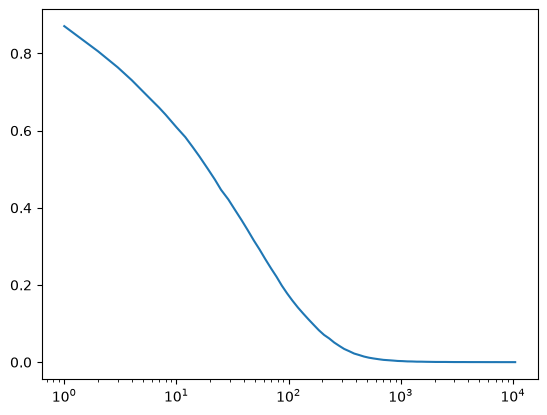

In [167]:
plt.plot(time_mat_stacked_hex[0], overlap_mat_stacked_hex[0])

plt.xscale("log")

# Analysis - Equilibration time

In [168]:
tau_list_hexagonal = np.array([
    find_relax_time(time_list, overlap_list)
    for time_list, overlap_list in zip(
        time_mat_hexagonal, overlap_mat_hexagonal,
        strict=True
    )
], dtype=float)

tau_list_square = np.array([
    find_relax_time(time_list, overlap_list)
    for time_list, overlap_list in zip(
        time_mat_square, overlap_mat_square,
        strict=True
    )
], dtype=float)

tau_list_triangular = np.array([
    find_relax_time(time_list, overlap_list)
    for time_list, overlap_list in zip(
        time_mat_triangular, overlap_mat_triangular,
        strict=True
    )
], dtype=float)

tau_list_king = np.array([
    find_relax_time(time_list, overlap_list)
    for time_list, overlap_list in zip(
        time_mat_king, overlap_mat_king,
        strict=True
    )
], dtype=float)

tau_list_cubic = np.array([
    find_relax_time(time_list, overlap_list)
    for time_list, overlap_list in zip(
        time_mat_cubic, overlap_mat_cubic,
        strict=True
    )
], dtype=float)

# Plots

## Single lattice type

### Hexagonal

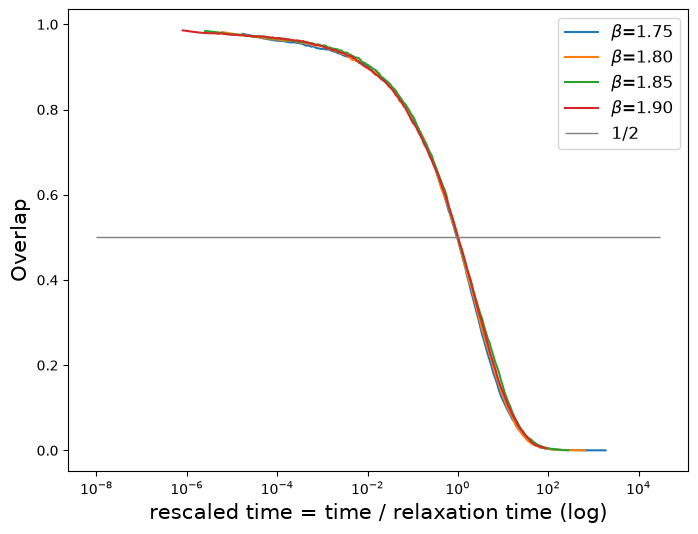

In [206]:
plot_start_idx = -5
plot_stop_idx = -1

plt.figure(figsize=(8,6))

for time_list, overlap_list, tau, beta in zip(
    time_mat_hexagonal[plot_start_idx:plot_stop_idx],
    overlap_mat_hexagonal[plot_start_idx:plot_stop_idx],
    tau_list_hexagonal[plot_start_idx:plot_stop_idx],
    beta_list_hexagonal[plot_start_idx:plot_stop_idx],
    strict=True
):

    if ~np.isnan(tau):
        plt.plot(time_list / tau, overlap_list, label=f'$\\beta$={beta:.2f}')

plt.hlines(.5, xmin=10**(-8), xmax=3 * 10**4, label='1/2', color='gray', linewidth=1)

plt.xscale("log")

plt.xlabel("rescaled time = time / relaxation time (log)", fontsize=fontsize_label)
plt.ylabel("Overlap", fontsize=fontsize_label)
# plt.title(
#     "Time-temperature superposition: Overlap curves' collapse | Hexagonal lattice", 
#     fontsize=fontsize_title-1
# )
plt.legend(fontsize=fontsize_legend)

### Square

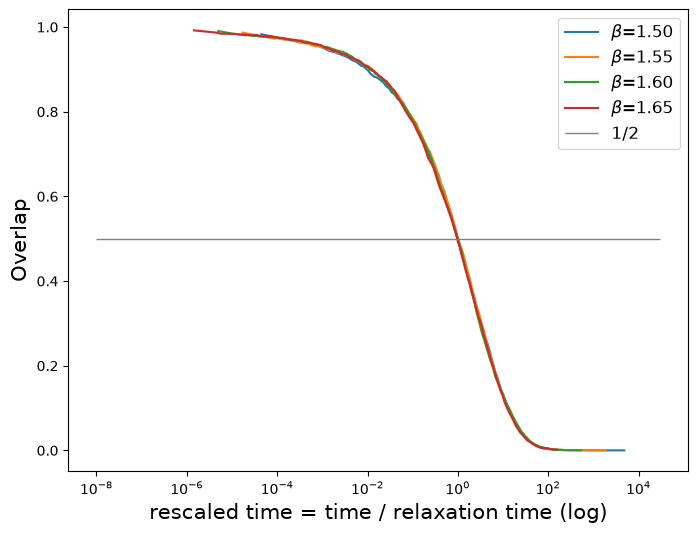

In [205]:
plot_start_idx = -7
plot_stop_idx = -3

plt.figure(figsize=(8,6))

for time_list, overlap_list, tau, beta in zip(
    time_mat_square[plot_start_idx:plot_stop_idx],
    overlap_mat_square[plot_start_idx:plot_stop_idx],
    tau_list_square[plot_start_idx:plot_stop_idx],
    beta_list_square[plot_start_idx:plot_stop_idx],
    strict=True
):

    if ~np.isnan(tau):
        plt.plot(time_list / tau, overlap_list, label=f'$\\beta$={beta:.2f}')

plt.hlines(.5, xmin=10**(-8), xmax=3 * 10**4, label='1/2', color='gray', linewidth=1)

plt.xscale("log")

plt.xlabel("rescaled time = time / relaxation time (log)", fontsize=fontsize_label)
plt.ylabel("Overlap", fontsize=fontsize_label)
# plt.title(
#     "Time-temperature superposition: Overlap curves' collapse | Square lattice", 
#     fontsize=fontsize_title-1
# )
plt.legend(fontsize=fontsize_legend)

### Triangular

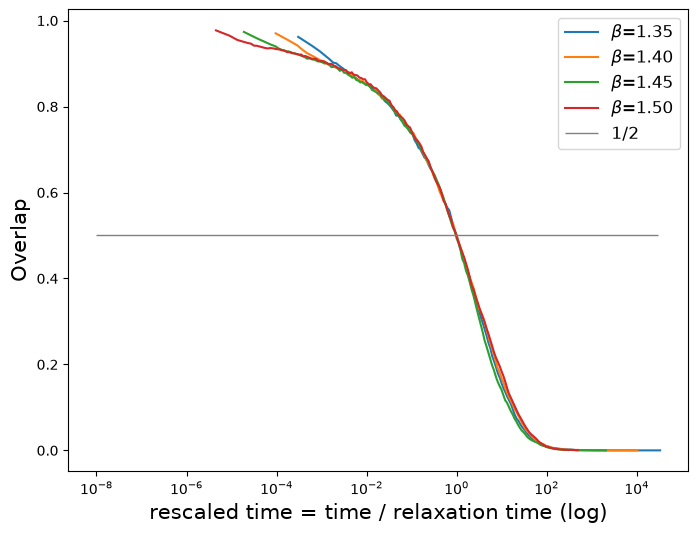

In [204]:
plot_start_idx = -8
plot_stop_idx = -4

plt.figure(figsize=(8,6))

for time_list, overlap_list, tau, beta in zip(
    time_mat_triangular[plot_start_idx:plot_stop_idx],
    overlap_mat_triangular[plot_start_idx:plot_stop_idx],
    tau_list_triangular[plot_start_idx:plot_stop_idx],
    beta_list_triangular[plot_start_idx:plot_stop_idx],
    strict=True
):

    if ~np.isnan(tau):
        plt.plot(time_list / tau, overlap_list, label=f'$\\beta$={beta:.2f}')

plt.hlines(.5, xmin=10**(-8), xmax=3 * 10**4, label='1/2', color='gray', linewidth=1)

plt.xscale("log")

plt.xlabel("rescaled time = time / relaxation time (log)", fontsize=fontsize_label)
plt.ylabel("Overlap", fontsize=fontsize_label)
# plt.title(
#     "Time-temperature superposition: Overlap curves' collapse | Triangular lattice", 
#     fontsize=fontsize_title-1
# )
plt.legend(fontsize=fontsize_legend)

### King

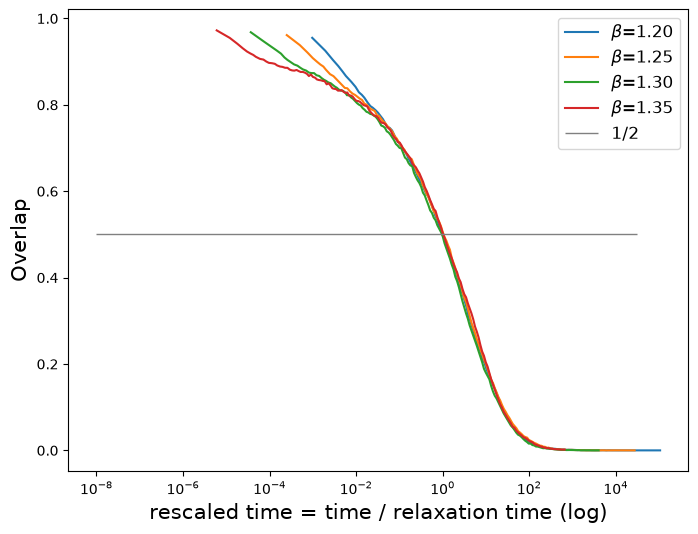

In [202]:
plot_start_idx = -7
plot_stop_idx = -3

plt.figure(figsize=(8,6))

for time_list, overlap_list, tau, beta in zip(
    time_mat_king[plot_start_idx:plot_stop_idx],
    overlap_mat_king[plot_start_idx:plot_stop_idx],
    tau_list_king[plot_start_idx:plot_stop_idx],
    beta_list_king[plot_start_idx:plot_stop_idx],
    strict=True
):

    if ~np.isnan(tau):
        plt.plot(time_list / tau, overlap_list, label=f'$\\beta$={beta:.2f}')

plt.hlines(.5, xmin=10**(-8), xmax=3 * 10**4, label='1/2', color='gray', linewidth=1)

plt.xscale("log")

plt.xlabel("rescaled time = time / relaxation time (log)", fontsize=fontsize_label)
plt.ylabel("Overlap", fontsize=fontsize_label)
# plt.title(
#     "Time-temperature superposition: Overlap curves' collapse | King lattice", 
#     fontsize=fontsize_title-1
# )
plt.legend(fontsize=fontsize_legend)

### Cubic

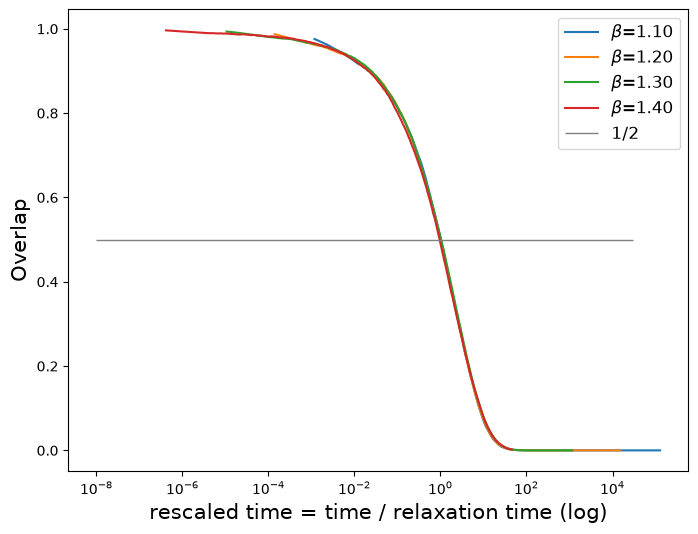

In [203]:
plot_start_idx = -4
plot_stop_idx = None

plt.figure(figsize=(8,6))

for time_list, overlap_list, tau, beta in zip(
    time_mat_cubic[plot_start_idx:plot_stop_idx],
    overlap_mat_cubic[plot_start_idx:plot_stop_idx],
    tau_list_cubic[plot_start_idx:plot_stop_idx],
    beta_list_cubic[plot_start_idx:plot_stop_idx],
    strict=True
):

    if ~np.isnan(tau):
        plt.plot(time_list / tau, overlap_list, label=f'$\\beta$={beta:.2f}')

plt.hlines(.5, xmin=10**(-8), xmax=3 * 10**4, label='1/2', color='gray', linewidth=1)

plt.xscale("log")

plt.xlabel("rescaled time = time / relaxation time (log)", fontsize=fontsize_label)
plt.ylabel("Overlap", fontsize=fontsize_label)
# plt.title(
#     "Time-temperature superposition: Overlap curves' collapse | Cubic lattice", 
#     fontsize=fontsize_title-1
# )
plt.legend(fontsize=fontsize_legend)

## Global plot

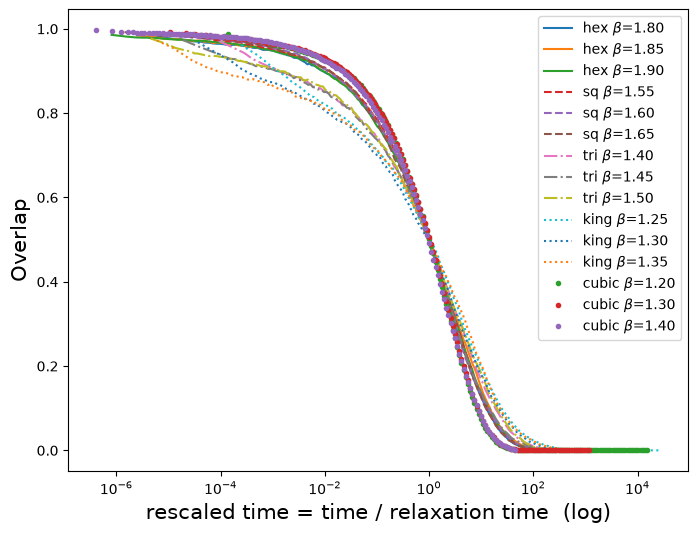

In [ ]:
plt.figure(figsize=(8,6))

# ===== Hexagonal =====
plot_start_idx = -4
plot_stop_idx = -1

for time_list, overlap_list, tau, beta in zip(
    time_mat_hexagonal[plot_start_idx:plot_stop_idx],
    overlap_mat_hexagonal[plot_start_idx:plot_stop_idx],
    tau_list_hexagonal[plot_start_idx:plot_stop_idx],
    beta_list_hexagonal[plot_start_idx:plot_stop_idx],
    strict=True
):

    if ~np.isnan(tau):
        plt.plot(
            time_list / tau, overlap_list, 
            label=f'hex $\\beta$={beta:.2f}',
            linestyle='solid'
        )

# ===== Square =====
plot_start_idx = -6
plot_stop_idx = -3

for time_list, overlap_list, tau, beta in zip(
    time_mat_square[plot_start_idx:plot_stop_idx],
    overlap_mat_square[plot_start_idx:plot_stop_idx],
    tau_list_square[plot_start_idx:plot_stop_idx],
    beta_list_square[plot_start_idx:plot_stop_idx],
    strict=True
):

    if ~np.isnan(tau):
        plt.plot(
            time_list / tau, overlap_list, 
            label=f'sq $\\beta$={beta:.2f}',
            linestyle='dashed'
        )

# ===== Triangular =====
plot_start_idx = -7
plot_stop_idx = -4

for time_list, overlap_list, tau, beta in zip(
    time_mat_triangular[plot_start_idx:plot_stop_idx],
    overlap_mat_triangular[plot_start_idx:plot_stop_idx],
    tau_list_triangular[plot_start_idx:plot_stop_idx],
    beta_list_triangular[plot_start_idx:plot_stop_idx],
    strict=True
):

    if ~np.isnan(tau):
        plt.plot(
            time_list / tau, overlap_list, 
            label=f'tri $\\beta$={beta:.2f}',
            linestyle='dashdot'
        )

# ===== King =====
plot_start_idx = -6
plot_stop_idx = -3

for time_list, overlap_list, tau, beta in zip(
    time_mat_king[plot_start_idx:plot_stop_idx],
    overlap_mat_king[plot_start_idx:plot_stop_idx],
    tau_list_king[plot_start_idx:plot_stop_idx],
    beta_list_king[plot_start_idx:plot_stop_idx],
    strict=True
):

    if ~np.isnan(tau):
        plt.plot(
            time_list / tau, overlap_list, 
            label=f'king $\\beta$={beta:.2f}', 
            linestyle='dotted'
        )

# ===== Cubic =====
plot_start_idx = -3
plot_stop_idx = None

for time_list, overlap_list, tau, beta in zip(
    time_mat_cubic[plot_start_idx:plot_stop_idx],
    overlap_mat_cubic[plot_start_idx:plot_stop_idx],
    tau_list_cubic[plot_start_idx:plot_stop_idx],
    beta_list_cubic[plot_start_idx:plot_stop_idx],
    strict=True
):

    if ~np.isnan(tau):
        plt.plot(
            time_list / tau, overlap_list, 
            label=f'cubic $\\beta$={beta:.2f}', 
            linestyle='',
            marker='.'
        )

# plt.hlines(.5, xmin=10**(-8), xmax=3 * 10**4, label='1/2', color='gray', linewidth=1)

plt.xscale("log")

plt.xlabel("rescaled time = time / relaxation time (log)", fontsize=fontsize_label)
plt.ylabel("Overlap", fontsize=fontsize_label)
# plt.title(
#     "Time-temperature superposition: Overlap curves' collapse | All lattices", 
#     fontsize=fontsize_title-1
# )
plt.legend(fontsize=fontsize_legend-2)

plt.savefig(f"{outdirpath_fig}/overlap_collapse_all.png", dpi=300, bbox_inches='tight')

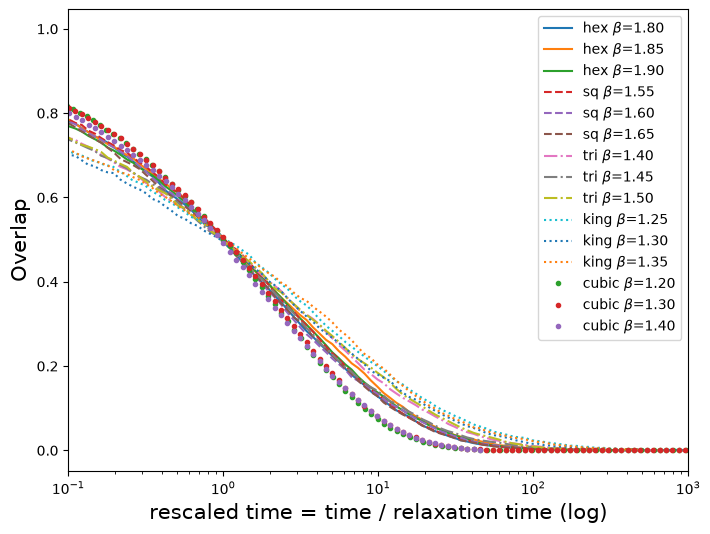

In [181]:
plt.figure(figsize=(8,6))

# ===== Hexagonal =====
plot_start_idx = -4
plot_stop_idx = -1

for time_list, overlap_list, tau, beta in zip(
    time_mat_hexagonal[plot_start_idx:plot_stop_idx],
    overlap_mat_hexagonal[plot_start_idx:plot_stop_idx],
    tau_list_hexagonal[plot_start_idx:plot_stop_idx],
    beta_list_hexagonal[plot_start_idx:plot_stop_idx],
    strict=True
):

    if ~np.isnan(tau):
        plt.plot(
            time_list / tau, overlap_list, 
            label=f'hex $\\beta$={beta:.2f}',
            linestyle='solid'
        )

# ===== Square =====
plot_start_idx = -6
plot_stop_idx = -3

for time_list, overlap_list, tau, beta in zip(
    time_mat_square[plot_start_idx:plot_stop_idx],
    overlap_mat_square[plot_start_idx:plot_stop_idx],
    tau_list_square[plot_start_idx:plot_stop_idx],
    beta_list_square[plot_start_idx:plot_stop_idx],
    strict=True
):

    if ~np.isnan(tau):
        plt.plot(
            time_list / tau, overlap_list, 
            label=f'sq $\\beta$={beta:.2f}',
            linestyle='dashed'
        )

# ===== Triangular =====
plot_start_idx = -7
plot_stop_idx = -4

for time_list, overlap_list, tau, beta in zip(
    time_mat_triangular[plot_start_idx:plot_stop_idx],
    overlap_mat_triangular[plot_start_idx:plot_stop_idx],
    tau_list_triangular[plot_start_idx:plot_stop_idx],
    beta_list_triangular[plot_start_idx:plot_stop_idx],
    strict=True
):

    if ~np.isnan(tau):
        plt.plot(
            time_list / tau, overlap_list, 
            label=f'tri $\\beta$={beta:.2f}',
            linestyle='dashdot'
        )

# ===== King =====
plot_start_idx = -6
plot_stop_idx = -3

for time_list, overlap_list, tau, beta in zip(
    time_mat_king[plot_start_idx:plot_stop_idx],
    overlap_mat_king[plot_start_idx:plot_stop_idx],
    tau_list_king[plot_start_idx:plot_stop_idx],
    beta_list_king[plot_start_idx:plot_stop_idx],
    strict=True
):

    if ~np.isnan(tau):
        plt.plot(
            time_list / tau, overlap_list, 
            label=f'king $\\beta$={beta:.2f}', 
            linestyle='dotted'
        )

# ===== Cubic =====
plot_start_idx = -3
plot_stop_idx = None

for time_list, overlap_list, tau, beta in zip(
    time_mat_cubic[plot_start_idx:plot_stop_idx],
    overlap_mat_cubic[plot_start_idx:plot_stop_idx],
    tau_list_cubic[plot_start_idx:plot_stop_idx],
    beta_list_cubic[plot_start_idx:plot_stop_idx],
    strict=True
):

    if ~np.isnan(tau):
        plt.plot(
            time_list / tau, overlap_list, 
            label=f'cubic $\\beta$={beta:.2f}', 
            linestyle='',
            marker='.'
        )

# plt.hlines(.5, xmin=10**(-8), xmax=3 * 10**4, label='1/2', color='gray', linewidth=1)

plt.xscale("log")

plt.xlim(0.1, 10**3)

plt.xlabel("rescaled time = time / relaxation time (log)", fontsize=fontsize_label)
plt.ylabel("Overlap", fontsize=fontsize_label)
# plt.title(
#     "Time-temperature superposition: Overlap curves' collapse | All lattices", 
#     fontsize=fontsize_title-1
# )
plt.legend(fontsize=fontsize_legend-2)

plt.savefig(f"{outdirpath_fig}/overlap_collapse_all_tail.png", dpi=300, bbox_inches='tight')

# Fit results - Stretched exponent:

In [152]:
def get_stretched_exp_fit_filepath(lattice, datapath=outdirpath_data):

    filepath = f"{datapath}/{lattice}_stretched_exp_fit.dat"

    return filepath

## Data loading

In [190]:
lattice_list = [
    "hexagonal", "triangular", "king", "cubic"
]

data_mat = [
    np.loadtxt(get_stretched_exp_fit_filepath(lattice)).T
    for lattice in lattice_list
]

beta_mat = [
    data_list[0] for data_list in data_mat
]

A_mat = [
    data_list[1] for data_list in data_mat
]

t0_mat = [
    data_list[2] for data_list in data_mat
]

alpha_mat = [
    data_list[3] for data_list in data_mat
]

In [192]:
marker_list = ["h", "^", "*", "s"]
color_list = ["red", "green", "orange", "blue"]

### Plot - A fit

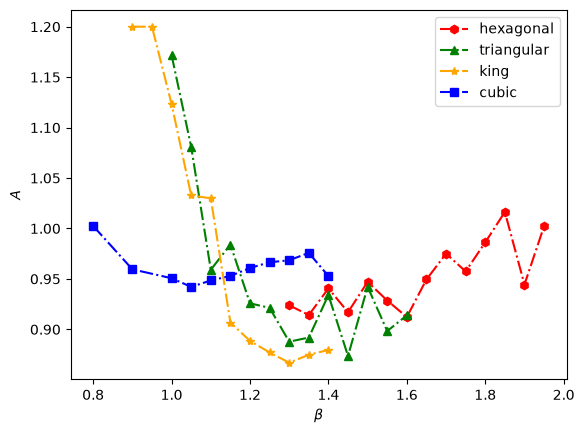

In [193]:
for beta_list, A_list, label, color, marker in zip(
    beta_mat, A_mat, lattice_list, color_list, marker_list
):

    plt.plot(
        beta_list, A_list,
        label=label,
        color=color,
        marker=marker,
        linestyle='-.'
    )

plt.xlabel("$\\beta$")
plt.ylabel("$A$")
plt.legend()

### Plot - t0 fit

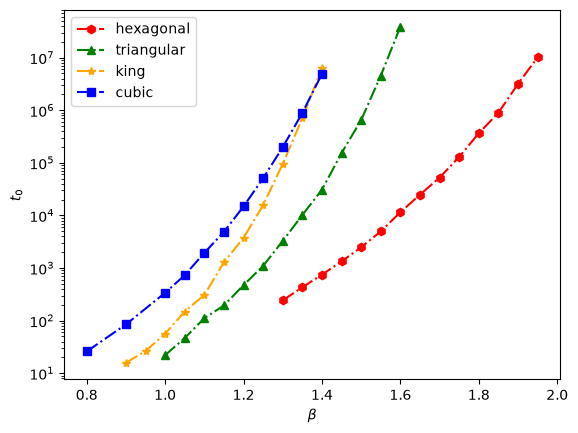

In [194]:
for beta_list, t0_list, label, color, marker in zip(
    beta_mat, t0_mat, lattice_list, color_list, marker_list
):

    plt.plot(
        beta_list, t0_list,
        label=label,
        color=color,
        marker=marker,
        linestyle='-.'
    )

plt.yscale("log")

plt.xlabel("$\\beta$")
plt.ylabel("$t_0$")
plt.legend()

### Plot - alpha fit

In [195]:
# Load reference alpha values
ref_square_alpha_filepath = "/net/debye/gmennella/randium/analysis/analysis_ref_data/ref_fit_result_all.dat"

ref_data = np.loadtxt(ref_square_alpha_filepath)

ref_beta_list = ref_data[0]
ref_alpha_list = ref_data[3]

print(ref_data.shape)

(4, 19)


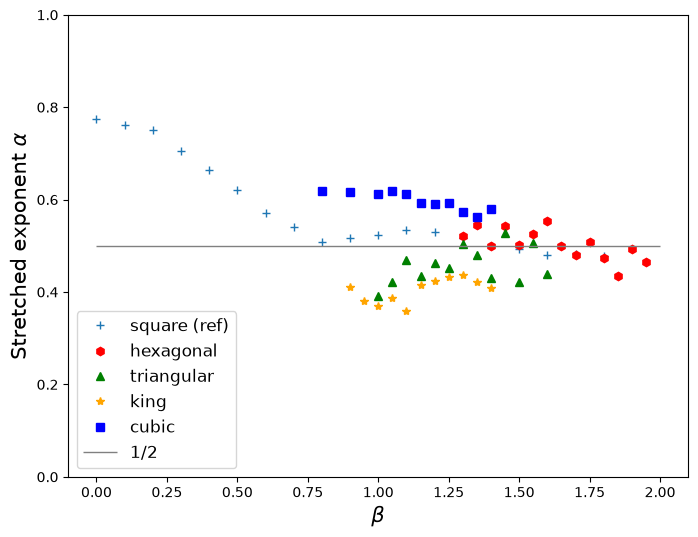

In [196]:
plt.figure(figsize=(8,6))

# Reference data
plt.plot(
    ref_beta_list, ref_alpha_list,
    label='square (ref)',
    linestyle='',
    marker='+'
)

# New data.
for beta_list, alpha_list, label, color, marker in zip(
    beta_mat, alpha_mat, lattice_list, color_list, marker_list
):

    plt.plot(
        beta_list, alpha_list,
        label=label,
        color=color,
        marker=marker,
        linestyle=''
    )

plt.hlines(
    .5, xmin=0, xmax=2,
    label='1/2',
    color='gray',
    linewidth=1
)

plt.ylim(0, 1)

plt.xlabel("$\\beta$", fontsize=fontsize_label)
plt.ylabel("Stretched exponent $\\alpha$", fontsize=fontsize_label)
plt.legend(fontsize=fontsize_legend, loc="lower left")
# plt.title(
#     "Stretched exponent vs inverse temperature by lattice",
#     fontsize=fontsize_title
# )

plt.savefig(
    f"{outdirpath_fig}/stretched_exp_vs_beta_all_lattice.png",
    dpi=300,
    bbox_inches="tight"
)